# Оценка опционов MM на фьючерс MXI

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

project_root = Path("/Users/maria/Desktop/Code/HSE/COURSEBOOK/final")
sys.path.insert(0, str(project_root))
from options_utils import (
    black76_price, american_futures_option_crr,
    compute_expanding_garch_forecast, add_model_block,
    restrict_to_common_sample, calc_metrics, calc_metrics_by_group,
    compute_tvnae_series, calc_tvnae_metrics,
    mean_error_test, dm_test_daily, price_with_alt_rate,
)

results_dir = project_root / "results_models"
figures_dir = results_dir / "figures_final"
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## EDA

### Загрузка датасета

In [2]:
data_path = project_root / "mm_options_with_mxi_underlying_2024_2026.parquet"
eda_df = pd.read_parquet(data_path)
eda_df["TRADEDATE"] = pd.to_datetime(eda_df["TRADEDATE"], errors="coerce")
eda_df["expiry_date"] = pd.to_datetime(eda_df["expiry_date"], errors="coerce")
eda_df.shape

(19574, 34)

### Структура и покрытие

In [3]:
pd.Series({
    "rows": len(eda_df),
    "unique_options": int(eda_df["SECID"].nunique()),
    "unique_underlyings": int(eda_df["UNDERLYING_SECID"].dropna().nunique()),
    "date_min": eda_df["TRADEDATE"].min().date(),
    "date_max": eda_df["TRADEDATE"].max().date(),
    "expiry_min": eda_df["expiry_date"].min().date(),
    "expiry_max": eda_df["expiry_date"].max().date(),
    "option_types": eda_df["option_type"].value_counts(dropna=False).to_dict(),
})

rows                                    19574
unique_options                             92
unique_underlyings                          5
date_min                           2024-01-03
date_max                           2026-05-19
expiry_min                         2026-04-16
expiry_max                         2027-06-17
option_types          {'C': 13217, 'P': 6357}
dtype: object

### Контракты underlying и строки по годам

In [4]:
display(eda_df["UNDERLYING_SHORTNAME"].value_counts().to_frame("rows"))
display(eda_df.groupby(eda_df["TRADEDATE"].dt.year).size().to_frame("rows"))

,rows
UNDERLYING_SHORTNAME,
MXI-6.26,11709
MXI-12.26,2472
MXI-9.26,2337
MXI-3.27,1785
MXI-6.27,1271


,rows
TRADEDATE,
2024,6921
2025,7359
2026,5294


### Пропуски в ключевых полях

In [5]:
eda_df[["market_price", "underlying_price", "moneyness",
        "UNDERLYING_CLOSE", "UNDERLYING_VOLUME"]].isna().mean().sort_values(ascending=False).to_frame("missing_share")

,missing_share
UNDERLYING_CLOSE,0.2744
UNDERLYING_VOLUME,0.2744
market_price,0.0000
underlying_price,0.0000
moneyness,0.0000


## Подготовка выборки

### Загрузка и типизация

In [6]:
df = pd.read_parquet(data_path)
df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"], errors="coerce").dt.normalize()
df["expiry_date"] = pd.to_datetime(df["expiry_date"], errors="coerce").dt.normalize()

for col in ["strike", "SETTLEPRICE", "market_price", "underlying_price",
            "UNDERLYING_SETTLEPRICE", "UNDERLYING_OPEN", "UNDERLYING_HIGH",
            "UNDERLYING_LOW", "UNDERLYING_CLOSE", "UNDERLYING_VALUE",
            "UNDERLYING_VOLUME", "UNDERLYING_OPENPOSITION", "UNDERLYING_NUMTRADES",
            "DTE_DAYS"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["market_price"] = df["SETTLEPRICE"]
df["F"] = df["underlying_price"]
df["K"] = df["strike"]
df["DTE_DAYS"] = (df["expiry_date"] - df["TRADEDATE"]).dt.days
df["T"] = df["DTE_DAYS"] / 365.0
df["r"] = 0.16
df["option_type_norm"] = df["option_type"].astype(str).str.upper().map({"C": "call", "P": "put"})
df["moneyness"] = df["F"] / df["K"]
df["log_moneyness"] = np.log(df["moneyness"])
df.shape

(19574, 39)

### Операционный фильтр

In [7]:
pd.Series({
    "bad_trade_date":      int(df["TRADEDATE"].isna().sum()),
    "bad_expiry_date":     int(df["expiry_date"].isna().sum()),
    "bad_market_price":    int((df["market_price"] <= 0).sum()),
    "bad_futures_price":   int((df["F"] <= 0).sum()),
    "bad_strike":          int((df["K"] <= 0).sum()),
    "bad_dte":             int((df["DTE_DAYS"] <= 0).sum()),
    "bad_option_type":     int((~df["option_type_norm"].isin(["call", "put"])).sum()),
    "bad_underlying_secid":int(df["UNDERLYING_SECID"].isna().sum()),
}).sort_values(ascending=False)

bad_dte                 9
bad_market_price        6
bad_trade_date          0
bad_expiry_date         0
bad_futures_price       0
bad_strike              0
bad_option_type         0
bad_underlying_secid    0
dtype: int64

In [8]:
mask = (
    df["TRADEDATE"].notna() & df["expiry_date"].notna()
    & (df["market_price"] > 0) & (df["F"] > 0) & (df["K"] > 0)
    & (df["DTE_DAYS"] > 0) & df["option_type_norm"].isin(["call", "put"])
    & df["UNDERLYING_SECID"].notna()
)
modelling_df = (df.loc[mask].copy()
                .sort_values(["TRADEDATE", "UNDERLYING_SECID", "expiry_date", "K", "option_type_norm"])
                .reset_index(drop=True))
print(f"Original: {len(df)}, Modelling: {len(modelling_df)}, Share: {len(modelling_df)/len(df):.4f}")

Original: 19574, Modelling: 19565, Share: 0.9995


### Диагностика хвостов

In [9]:
pd.Series({
    "share_moneyness_lt_0.7":           float((modelling_df["moneyness"] < 0.7).mean()),
    "share_moneyness_gt_1.8":           float((modelling_df["moneyness"] > 1.8).mean()),
    "share_dte_gt_365":                 float((modelling_df["DTE_DAYS"] > 365).mean()),
    "share_market_price_gt_K_plus_F":   float((modelling_df["market_price"] > (modelling_df["K"] + modelling_df["F"])).mean()),
})

share_moneyness_lt_0.7           0.0000
share_moneyness_gt_1.8           0.0355
share_dte_gt_365                 0.6048
share_market_price_gt_K_plus_F   0.0000
dtype: float64

## Волатильность и режимы

### Исторические волатильности и режимы

In [10]:
underlying_daily = (
    modelling_df[["TRADEDATE", "UNDERLYING_SECID", "UNDERLYING_SHORTNAME", "F"]]
    .drop_duplicates().sort_values(["UNDERLYING_SECID", "TRADEDATE"]).reset_index(drop=True)
)
underlying_daily["ret_1d"] = underlying_daily.groupby("UNDERLYING_SECID")["F"].transform(
    lambda s: np.log(s).diff()
)
underlying_daily["ret_21d"] = underlying_daily.groupby("UNDERLYING_SECID")["F"].transform(
    lambda s: np.log(s / s.shift(21))
)
underlying_daily["hv_21d"] = underlying_daily.groupby("UNDERLYING_SECID")["ret_1d"].transform(
    lambda s: s.rolling(21).std() * np.sqrt(252)
)
underlying_daily["hv_63d"] = underlying_daily.groupby("UNDERLYING_SECID")["ret_1d"].transform(
    lambda s: s.rolling(63).std() * np.sqrt(252)
)
vol_q = underlying_daily["hv_21d"].dropna().quantile([1/3, 2/3]).to_dict()
underlying_daily["vol_regime"] = pd.cut(
    underlying_daily["hv_21d"],
    bins=[-np.inf, vol_q[1/3], vol_q[2/3], np.inf],
    labels=["low_vol", "mid_vol", "high_vol"],
)
underlying_daily["trend_regime"] = np.select(
    [underlying_daily["ret_21d"] > 0, underlying_daily["ret_21d"] <= 0],
    ["up", "down"], default=pd.NA,
)
underlying_daily["regime_label"] = np.where(
    underlying_daily["vol_regime"].isna(), pd.NA,
    underlying_daily["vol_regime"].astype(str) + "_" + underlying_daily["trend_regime"],
)
modelling_df = modelling_df.merge(
    underlying_daily[["TRADEDATE", "UNDERLYING_SECID", "ret_1d", "ret_21d",
                       "hv_21d", "hv_63d", "vol_regime", "trend_regime", "regime_label"]],
    on=["TRADEDATE", "UNDERLYING_SECID"], how="left",
)
modelling_df[["TRADEDATE", "UNDERLYING_SECID", "F", "hv_21d", "hv_63d", "vol_regime"]].head()

,TRADEDATE,UNDERLYING_SECID,F,hv_21d,hv_63d,vol_regime
0,2024-01-03,MMH7,"4,575.4500",NaN,NaN,NaN
1,2024-01-03,MMH7,"4,575.4500",NaN,NaN,NaN
2,2024-01-03,MMM6,"4,080.2500",NaN,NaN,NaN
3,2024-01-03,MMM6,"4,080.2500",NaN,NaN,NaN
4,2024-01-03,MMM6,"4,080.2500",NaN,NaN,NaN


## GARCH

### Expanding forecast (без look-ahead bias)

In [11]:
garch_forecasts = compute_expanding_garch_forecast(underlying_daily, min_obs=63, refit_every=21)
modelling_df = modelling_df.merge(garch_forecasts, on=["TRADEDATE", "UNDERLYING_SECID"], how="left")
print("garch non-null share:", round(float(modelling_df["garch_vol"].notna().mean()), 4))

garch non-null share: 0.923


## Ценовые модели

### Расчёт модельных цен (CRR и Black-76)

In [12]:
pricing_df = modelling_df.copy()
pricing_df = add_model_block(pricing_df, "hv_21d",   "crr_hv_21d",      use_american=True,  steps=100)
pricing_df = add_model_block(pricing_df, "hv_63d",   "crr_hv_63d",      use_american=True,  steps=100)
pricing_df = add_model_block(pricing_df, "garch_vol","crr_garch",        use_american=True,  steps=100)
pricing_df = add_model_block(pricing_df, "hv_63d",   "black76_hv_63d",  use_american=False)

### Сегментация выборки

In [13]:
pricing_df["moneyness_bucket"] = pd.cut(
    pricing_df["moneyness"],
    bins=[0, 0.9, 0.97, 1.03, 1.1, np.inf],
    labels=["deep_OTM", "OTM", "ATM", "ITM", "deep_ITM"],
)
pricing_df["DTE_bucket"] = pd.cut(
    pricing_df["DTE_DAYS"],
    bins=[0, 7, 30, 90, np.inf],
    labels=["0-7", "8-30", "31-90", "91+"],
)
pricing_df["abs_log_moneyness"] = pricing_df["log_moneyness"].abs()
pricing_df[["SECID", "TRADEDATE", "market_price", "F", "K",
            "model_price_crr_hv_21d", "model_price_crr_hv_63d",
            "model_price_crr_garch", "model_price_black76_hv_63d"]].head()

,SECID,TRADEDATE,market_price,F,K,model_price_crr_hv_21d,model_price_crr_hv_63d,model_price_crr_garch,model_price_black76_hv_63d
0,MM3150BC7,2024-01-03,"1,513.8000","4,575.4500","3,150.0000",NaN,NaN,NaN,NaN
1,MM3200BC7,2024-01-03,"1,470.1000","4,575.4500","3,200.0000",NaN,NaN,NaN,NaN
2,MM2500BR6,2024-01-03,37.5500,"4,080.2500","2,500.0000",NaN,NaN,NaN,NaN
3,MM2550BR6,2024-01-03,40.4500,"4,080.2500","2,550.0000",NaN,NaN,NaN,NaN
4,MM2600BF6,2024-01-03,"1,523.9000","4,080.2500","2,600.0000",NaN,NaN,NaN,NaN


## Сравнение моделей

### Наборы моделей и общая выборка

In [14]:
american_models = {
    "CRR + hv_21d": {
        "price": "model_price_crr_hv_21d", "err": "error_crr_hv_21d",
        "abs": "abs_error_crr_hv_21d", "sq": "squared_error_crr_hv_21d",
        "pct": "pct_error_crr_hv_21d",
    },
    "CRR + hv_63d": {
        "price": "model_price_crr_hv_63d", "err": "error_crr_hv_63d",
        "abs": "abs_error_crr_hv_63d", "sq": "squared_error_crr_hv_63d",
        "pct": "pct_error_crr_hv_63d",
    },
    "CRR + garch": {
        "price": "model_price_crr_garch", "err": "error_crr_garch",
        "abs": "abs_error_crr_garch", "sq": "squared_error_crr_garch",
        "pct": "pct_error_crr_garch",
    },
}
euro_benchmark = {
    "Black-76 + hv_63d": {
        "price": "model_price_black76_hv_63d", "err": "error_black76_hv_63d",
        "abs": "abs_error_black76_hv_63d", "sq": "squared_error_black76_hv_63d",
        "pct": "pct_error_black76_hv_63d",
    }
}
american_common = restrict_to_common_sample(pricing_df, american_models)
all_models_common = restrict_to_common_sample(pricing_df, american_models | euro_benchmark)
pd.DataFrame({
    "sample": ["american only", "american + black76"],
    "rows": [len(american_common), len(all_models_common)],
    "date_min": [american_common["TRADEDATE"].min(), all_models_common["TRADEDATE"].min()],
    "date_max": [american_common["TRADEDATE"].max(), all_models_common["TRADEDATE"].max()],
})

,sample,rows,date_min,date_max
0,american only,18058,2024-04-04,2026-05-19
1,american + black76,18058,2024-04-04,2026-05-19


### Общие метрики

In [15]:
overall_american = pd.DataFrame([
    {"model": name, **calc_metrics(american_common, spec)}
    for name, spec in american_models.items()
]).sort_values("MAE").reset_index(drop=True)
display(overall_american)

,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,CRR + garch,18058,107.0076,145.7618,-78.1416,82.8816,2.2261
1,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
2,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664


## TVNAE

### Нормированная ошибка по временно́й стоимости

In [16]:
TV_THRESHOLD = 10.0

tvnae_overall = pd.DataFrame([
    {"model": name, **calc_tvnae_metrics(american_common, spec, tv_threshold=TV_THRESHOLD)}
    for name, spec in american_models.items()
]).sort_values("mean_TVNAE").reset_index(drop=True)
display(tvnae_overall)

tvnae_by_regime = pd.concat([
    calc_tvnae_metrics(american_common, spec, "vol_regime", TV_THRESHOLD).assign(model=name)
    for name, spec in american_models.items()
], ignore_index=True)
display(tvnae_by_regime.pivot(index="model", columns="vol_regime", values="mean_TVNAE").round(3))

tvnae_by_dte = pd.concat([
    calc_tvnae_metrics(american_common, spec, "DTE_bucket", TV_THRESHOLD).assign(model=name)
    for name, spec in american_models.items()
], ignore_index=True)
display(tvnae_by_dte.pivot(index="model", columns="DTE_bucket", values="mean_TVNAE").round(3))

,model,N_filtered,mean_TVNAE,median_TVNAE
0,CRR + garch,16961,0.6598,0.6242
1,CRR + hv_63d,16961,0.6958,0.6805
2,CRR + hv_21d,16961,0.7631,0.7782


vol_regime,low_vol,mid_vol,high_vol
model,,,
CRR + garch,0.6280,0.6500,0.7160
CRR + hv_21d,0.8400,0.7380,0.6800
CRR + hv_63d,0.7110,0.6890,0.6800


DTE_bucket,0-7,8-30,31-90,91+
model,,,,
CRR + garch,0.1890,0.2880,0.5260,0.6820
CRR + hv_21d,0.4000,0.5500,0.7770,0.7660
CRR + hv_63d,0.5940,0.6530,0.7750,0.6880


## Ошибки по сегментам

### Разбивка по режиму, DTE, moneyness

In [17]:
breakdown_tables = {}
for group_col, title in [
    ("vol_regime",       "По режиму волатильности"),
    ("DTE_bucket",       "По DTE bucket"),
    ("moneyness_bucket", "По moneyness bucket"),
]:
    tables = []
    for name, spec in american_models.items():
        t = calc_metrics_by_group(american_common, spec, group_col)
        t["model"] = name
        tables.append(t)
    breakdown_tables[group_col] = pd.concat(tables, ignore_index=True)
    print(title)
    display(breakdown_tables[group_col])

По режиму волатильности


,vol_regime,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,low_vol,7684,104.1175,-103.8176,76.3250,143.8927,0.8449,CRR + hv_21d
1,mid_vol,5519,141.8138,-141.3150,123.6820,173.7385,0.6019,CRR + hv_21d
2,high_vol,4855,117.7635,-29.3552,94.9370,154.6367,11.9876,CRR + hv_21d
3,low_vol,7684,82.0777,-78.7946,58.6537,118.3153,1.3068,CRR + hv_63d
4,mid_vol,5519,128.2599,-123.5354,109.3975,158.5346,0.7803,CRR + hv_63d
5,high_vol,4855,122.8302,-68.5892,104.1905,151.1148,11.0505,CRR + hv_63d
6,low_vol,7684,77.4920,-76.1009,51.3248,112.5265,0.8274,CRR + garch
7,mid_vol,5519,118.1952,-111.0773,102.6401,145.9819,0.7102,CRR + garch
8,high_vol,4855,141.0041,-43.9312,114.8496,186.4399,6.1629,CRR + garch


По DTE bucket


,DTE_bucket,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,0-7,126,2.7788,-2.7775,1.3481,4.2976,0.6270,CRR + hv_21d
1,8-30,503,8.7048,-8.6902,7.0695,11.7482,0.5741,CRR + hv_21d
2,31-90,2104,36.3819,-36.3787,32.1827,46.8306,0.6095,CRR + hv_21d
3,91+,15325,135.2806,-106.9435,113.9496,168.8844,4.3304,CRR + hv_21d
4,0-7,126,3.5261,-3.5261,1.6500,5.3778,0.6831,CRR + hv_63d
5,8-30,503,10.0973,-10.0973,8.4352,13.0423,0.6315,CRR + hv_63d
6,31-90,2104,35.3924,-35.3330,33.0024,45.1145,0.6079,CRR + hv_63d
7,91+,15325,121.0378,-100.5146,99.2964,151.7211,4.3273,CRR + hv_63d
8,0-7,126,1.8810,-1.5594,1.1760,2.7786,0.6873,CRR + garch
9,8-30,503,4.8730,-2.8837,3.3450,6.9155,0.3999,CRR + garch


По moneyness bucket


,moneyness_bucket,N,MAE,mean_error,median_abs_error,RMSE,mean_abs_pct_error,model
0,deep_OTM,266,63.3795,-62.3481,53.8878,86.2274,0.8464,CRR + hv_21d
1,OTM,1531,97.0469,-95.4718,93.3123,121.0248,1.1518,CRR + hv_21d
2,ATM,1950,94.1247,-88.0723,75.6108,122.5239,0.4839,CRR + hv_21d
3,ITM,3117,129.2325,-106.0375,106.0229,165.1159,0.8368,CRR + hv_21d
4,deep_ITM,11194,125.3040,-94.2612,99.6742,164.5588,5.5810,CRR + hv_21d
5,deep_OTM,266,61.5161,-60.6991,54.4320,81.5663,0.8431,CRR + hv_63d
6,OTM,1531,90.6570,-88.6047,87.0781,110.1471,1.5098,CRR + hv_63d
7,ATM,1950,88.5536,-83.8090,71.2310,111.8376,0.4811,CRR + hv_63d
8,ITM,3117,115.2119,-94.1833,89.9017,145.9576,1.3183,CRR + hv_63d
9,deep_ITM,11194,111.4828,-90.3568,85.7352,148.2446,5.3971,CRR + hv_63d


## Бенчмарк Black-76

### European benchmark и early exercise premium

In [18]:
benchmark_compare = pd.DataFrame([
    {"model": name, **calc_metrics(all_models_common, spec)}
    for name, spec in (american_models | euro_benchmark).items()
]).sort_values("MAE").reset_index(drop=True)
display(benchmark_compare)

all_models_common["early_exercise_premium"] = (
    all_models_common["model_price_crr_hv_63d"] - all_models_common["model_price_black76_hv_63d"]
)
premium_summary = (
    all_models_common.groupby(["vol_regime", "DTE_bucket"], dropna=False, observed=False)
    ["early_exercise_premium"].agg(["count", "mean", "median"]).reset_index()
)
display(premium_summary)

black_below_intrinsic = np.where(
    all_models_common["option_type_norm"].eq("call"),
    all_models_common["model_price_black76_hv_63d"] < np.maximum(all_models_common["F"] - all_models_common["K"], 0),
    all_models_common["model_price_black76_hv_63d"] < np.maximum(all_models_common["K"] - all_models_common["F"], 0),
)
pd.DataFrame({
    "metric": ["N common sample", "share Black-76 below intrinsic",
               "mean early exercise premium", "median early exercise premium"],
    "value": [len(all_models_common), float(np.mean(black_below_intrinsic)),
              float(all_models_common["early_exercise_premium"].mean()),
              float(all_models_common["early_exercise_premium"].median())],
})

,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,CRR + garch,18058,107.0076,145.7618,-78.1416,82.8816,2.2261
1,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
2,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664
3,Black-76 + hv_63d,18058,156.1648,211.6440,-149.0030,109.9674,3.6200


,vol_regime,DTE_bucket,count,mean,median
0,low_vol,0-7,45,0.0476,-0.0000
1,low_vol,8-30,417,0.2193,0.0006
2,low_vol,31-90,1950,2.1310,0.1188
3,low_vol,91+,5272,40.6606,4.9326
4,mid_vol,0-7,81,0.0520,-0.0000
5,mid_vol,8-30,86,0.8005,-0.0000
6,mid_vol,31-90,154,2.8112,0.0434
7,mid_vol,91+,5198,64.8288,25.1753
8,high_vol,0-7,0,NaN,NaN
9,high_vol,8-30,0,NaN,NaN


,metric,value
0,N common sample,"18,058.0000"
1,share Black-76 below intrinsic,0.2452
2,mean early exercise premium,59.2782
3,median early exercise premium,9.8698


## Эконометрические тесты

### Тест на нулевую среднюю ошибку

In [19]:
mean_error_tests = pd.DataFrame([
    mean_error_test(american_common, spec, name)
    for name, spec in american_models.items()
]).sort_values("p_value").reset_index(drop=True)
display(mean_error_tests)

,model,N,mean_error,std_error_clustered,t_stat,p_value
0,CRR + hv_63d,18058,-89.7248,3.6218,-24.7738,0.0000
1,CRR + hv_21d,18058,-95.2581,4.1137,-23.1563,0.0000
2,CRR + garch,18058,-78.1416,3.8351,-20.3754,0.0000


### Pairwise DM-тесты

In [20]:
model_names = list(american_models.keys())
pairwise_sq, pairwise_abs = [], []
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        a, b = model_names[i], model_names[j]
        pairwise_sq.append(dm_test_daily(american_common, american_models[a], american_models[b], a, b, "sq"))
        pairwise_abs.append(dm_test_daily(american_common, american_models[a], american_models[b], a, b, "abs"))

dm_sq_table = pd.DataFrame(pairwise_sq).sort_values("comparison").reset_index(drop=True)
dm_abs_table = pd.DataFrame(pairwise_abs).sort_values("comparison").reset_index(drop=True)
print("MSE loss differential")
display(dm_sq_table)
print("MAE loss differential")
display(dm_abs_table)

MSE loss differential


,comparison,loss_metric,N_trade_dates,mean_loss_diff,std_error_hac,t_stat,p_value
0,CRR + hv_21d minus CRR + garch,MSE,540,"3,434.5536","1,929.6565",1.7799,0.0751
1,CRR + hv_21d minus CRR + hv_63d,MSE,540,"5,142.0180","1,143.2267",4.4978,0.0000
2,CRR + hv_63d minus CRR + garch,MSE,540,"-1,707.4644","1,905.1700",-0.8962,0.3701


MAE loss differential


,comparison,loss_metric,N_trade_dates,mean_loss_diff,std_error_hac,t_stat,p_value
0,CRR + hv_21d minus CRR + garch,MAE,540,11.7450,4.0959,2.8675,0.0041
1,CRR + hv_21d minus CRR + hv_63d,MAE,540,12.9893,3.6015,3.6067,0.0003
2,CRR + hv_63d minus CRR + garch,MAE,540,-1.2443,4.2507,-0.2927,0.7697


### OLS на ошибках (3 спецификации)

In [21]:
ols_df = american_common[["TRADEDATE", "abs_error_crr_hv_63d", "vol_regime",
                          "DTE_DAYS", "log_moneyness", "option_type_norm"]].dropna().copy()
ols_df["high_vol_dummy"] = (ols_df["vol_regime"] == "high_vol").astype(int)
ols_df["abs_log_moneyness"] = ols_df["log_moneyness"].abs()
ols_df["cluster"] = ols_df["TRADEDATE"].astype(str)

ols1 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy", data=ols_df).fit(
    cov_type="cluster", cov_kwds={"groups": ols_df["cluster"]}
)
ols2 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness", data=ols_df).fit(
    cov_type="cluster", cov_kwds={"groups": ols_df["cluster"]}
)
ols3 = smf.ols("abs_error_crr_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness + C(option_type_norm)", data=ols_df).fit(
    cov_type="cluster", cov_kwds={"groups": ols_df["cluster"]}
)
print(ols1.summary())
print(ols2.summary())
print(ols3.summary())

                             OLS Regression Results                             
Dep. Variable:     abs_error_crr_hv_63d   R-squared:                       0.011
Model:                              OLS   Adj. R-squared:                  0.011
Method:                   Least Squares   F-statistic:                     15.40
Date:                  Thu, 11 Jun 2026   Prob (F-statistic):           9.82e-05
Time:                          13:19:34   Log-Likelihood:            -1.0700e+05
No. Observations:                 18058   AIC:                         2.140e+05
Df Residuals:                     18056   BIC:                         2.140e+05
Df Model:                             1                                         
Covariance Type:                cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        101.382

## Чувствительность к ставке

### Grid по r

In [22]:
rate_rows = []
for r_val in [0.12, 0.16, 0.20]:
    tmp = price_with_alt_rate(american_common, "hv_63d", r_val, steps=100)
    valid = tmp["model_price"].notna()
    rate_rows.append({
        "r": r_val, "N": int(valid.sum()),
        "MAE": float(tmp.loc[valid, "abs_error"].mean()),
        "RMSE": float(np.sqrt(tmp.loc[valid, "sq_error"].mean())),
        "mean_error": float(tmp.loc[valid, "error"].mean()),
        "mean_abs_pct_error": float(tmp.loc[valid, "pct_error"].abs().mean()),
    })
pd.DataFrame(rate_rows).sort_values("MAE").reset_index(drop=True)

,r,N,MAE,RMSE,mean_error,mean_abs_pct_error
0,0.1200,18058,104.5747,137.5282,-81.9568,3.9286
1,0.1600,18058,107.1488,140.6325,-89.7248,3.7655
2,0.2000,18058,109.8357,144.0606,-96.3049,3.6159


## Robustness

### Альтернативные подвыборки

In [23]:
robustness_samples = {
    "full":              american_common,
    "excl_deep_tails":   american_common.loc[~american_common["moneyness_bucket"].astype(str).isin(["deep_OTM", "deep_ITM"])].copy(),
    "short_dte_le_91":   american_common.loc[american_common["DTE_DAYS"] <= 91].copy(),
    "long_dte_gt_91":    american_common.loc[american_common["DTE_DAYS"] > 91].copy(),
    "non_high_vol":      american_common.loc[american_common["vol_regime"] != "high_vol"].copy(),
}
robustness_rows = []
for sname, sdf in robustness_samples.items():
    for mname, spec in american_models.items():
        robustness_rows.append({"sample": sname, "model": mname, **calc_metrics(sdf, spec)})
robustness_table = pd.DataFrame(robustness_rows).sort_values(["sample", "MAE"]).reset_index(drop=True)
display(robustness_table)

,sample,model,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,excl_deep_tails,CRR + garch,6598,92.7563,131.1402,-68.0807,70.8032,0.7921
1,excl_deep_tails,CRR + hv_63d,6598,101.6355,128.7476,-89.8228,83.8427,1.1153
2,excl_deep_tails,CRR + hv_21d,6598,111.3883,143.9272,-98.2763,94.6771,0.8056
3,full,CRR + garch,18058,107.0076,145.7618,-78.1416,82.8816,2.2261
4,full,CRR + hv_63d,18058,107.1488,140.6325,-89.7248,84.4516,3.7655
5,full,CRR + hv_21d,18058,119.3073,156.4121,-95.2581,96.8427,3.7664
6,long_dte_gt_91,CRR + hv_63d,15279,121.1959,151.8946,-100.6110,99.5050,4.3384
7,long_dte_gt_91,CRR + garch,15279,122.7081,157.9017,-88.7130,99.3637,2.5413
8,long_dte_gt_91,CRR + hv_21d,15279,135.4394,169.0633,-107.0170,114.1430,4.3413
9,non_high_vol,CRR + garch,13203,94.5064,127.5828,-90.7214,72.9173,0.7784


## Графики

### MAE по моделям и сегментам

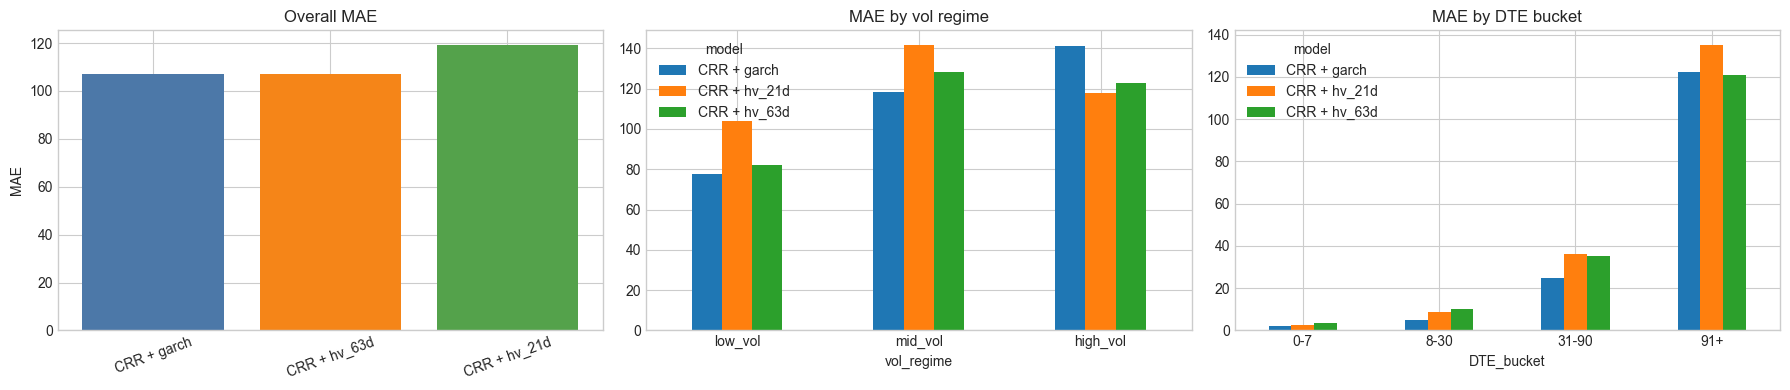

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(overall_american["model"], overall_american["MAE"],
            color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Overall MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

vol_plot = (breakdown_tables["vol_regime"].dropna(subset=["vol_regime"])
            .pivot(index="vol_regime", columns="model", values="MAE"))
vol_plot.plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE by vol regime")
axes[1].tick_params(axis="x", rotation=0)

dte_plot = (breakdown_tables["DTE_bucket"].dropna(subset=["DTE_bucket"])
            .pivot(index="DTE_bucket", columns="model", values="MAE"))
dte_plot.plot(kind="bar", ax=axes[2])
axes[2].set_title("MAE by DTE bucket")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(figures_dir / "fig_01_03_model_comparison.png", dpi=150)
plt.show()

### Rolling MAE

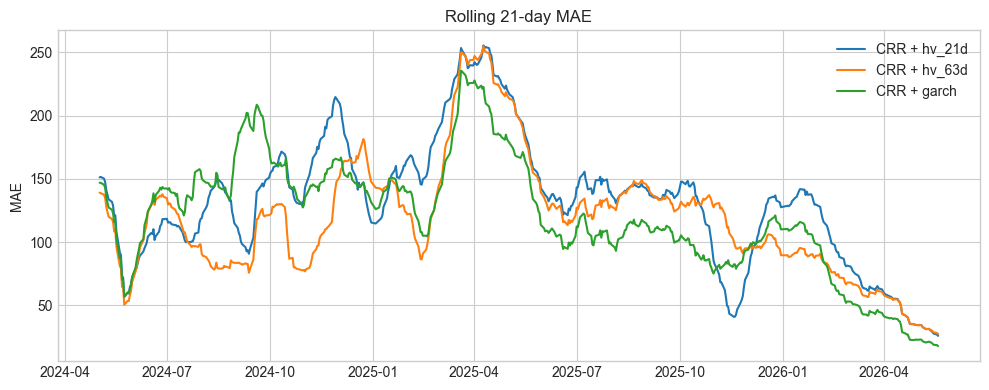

In [25]:
rolling = (
    american_common.groupby("TRADEDATE")[
        ["abs_error_crr_hv_21d", "abs_error_crr_hv_63d", "abs_error_crr_garch"]
    ].mean().rolling(21).mean().reset_index()
)
plt.figure(figsize=(10, 4))
plt.plot(rolling["TRADEDATE"], rolling["abs_error_crr_hv_21d"], label="CRR + hv_21d")
plt.plot(rolling["TRADEDATE"], rolling["abs_error_crr_hv_63d"], label="CRR + hv_63d")
plt.plot(rolling["TRADEDATE"], rolling["abs_error_crr_garch"],  label="CRR + garch")
plt.title("Rolling 21-day MAE")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "fig_04_rolling_mae.png", dpi=150)
plt.show()

### Early exercise premium по DTE

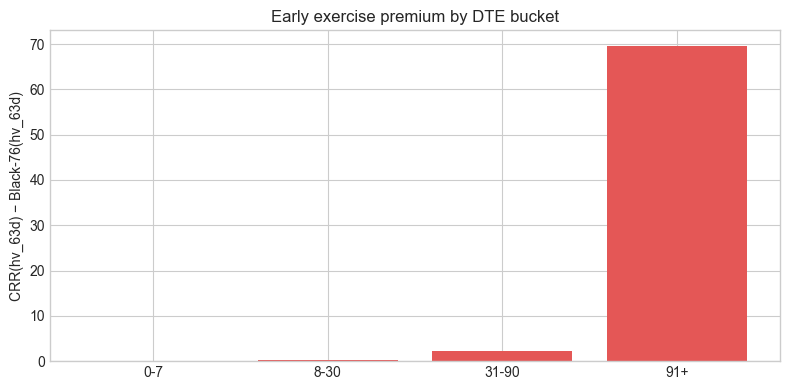

In [26]:
prem_by_dte = (
    all_models_common.groupby("DTE_bucket", dropna=False, observed=False)["early_exercise_premium"]
    .mean().reset_index()
)
plt.figure(figsize=(8, 4))
plt.bar(prem_by_dte["DTE_bucket"].astype(str), prem_by_dte["early_exercise_premium"],
        color="#E45756")
plt.title("Early exercise premium by DTE bucket")
plt.ylabel("CRR(hv_63d) − Black-76(hv_63d)")
plt.tight_layout()
plt.savefig(figures_dir / "fig_05_early_exercise_premium_by_dte.png", dpi=150)
plt.show()

## Сохранение артефактов

In [27]:
modelling_df.to_parquet(results_dir / "modelling_sample_mxi_clean.parquet", index=False)
pricing_df.to_parquet(results_dir / "pricing_results_mxi_clean.parquet", index=False)

overall_american.to_csv(results_dir / "overall_american_models.csv", index=False)
breakdown_tables["vol_regime"].to_csv(results_dir / "breakdown_by_vol_regime.csv", index=False)
breakdown_tables["DTE_bucket"].to_csv(results_dir / "breakdown_by_dte_bucket.csv", index=False)
breakdown_tables["moneyness_bucket"].to_csv(results_dir / "breakdown_by_moneyness_bucket.csv", index=False)
benchmark_compare.to_csv(results_dir / "benchmark_compare_with_black76.csv", index=False)
premium_summary.to_csv(results_dir / "early_exercise_premium_summary.csv", index=False)
mean_error_tests.to_csv(results_dir / "mean_error_tests.csv", index=False)
dm_sq_table.to_csv(results_dir / "pairwise_dm_sq.csv", index=False)
dm_abs_table.to_csv(results_dir / "pairwise_dm_abs.csv", index=False)
robustness_table.to_csv(results_dir / "robustness_checks.csv", index=False)
tvnae_overall.to_csv(results_dir / "tvnae_overall.csv", index=False)
tvnae_by_regime.to_csv(results_dir / "tvnae_by_vol_regime.csv", index=False)
tvnae_by_dte.to_csv(results_dir / "tvnae_by_dte.csv", index=False)

ols_text = ("OLS SPECIFICATION 1\n" + ols1.summary().as_text()
            + "\n\nOLS SPECIFICATION 2\n" + ols2.summary().as_text()
            + "\n\nOLS SPECIFICATION 3\n" + ols3.summary().as_text())
(results_dir / "error_ols_results.txt").write_text(ols_text)

print("Saved to:", results_dir)

Saved to: /Users/maria/Desktop/Code/HSE/COURSEBOOK/final/results_models


## Дополнительные визуализации для презентации

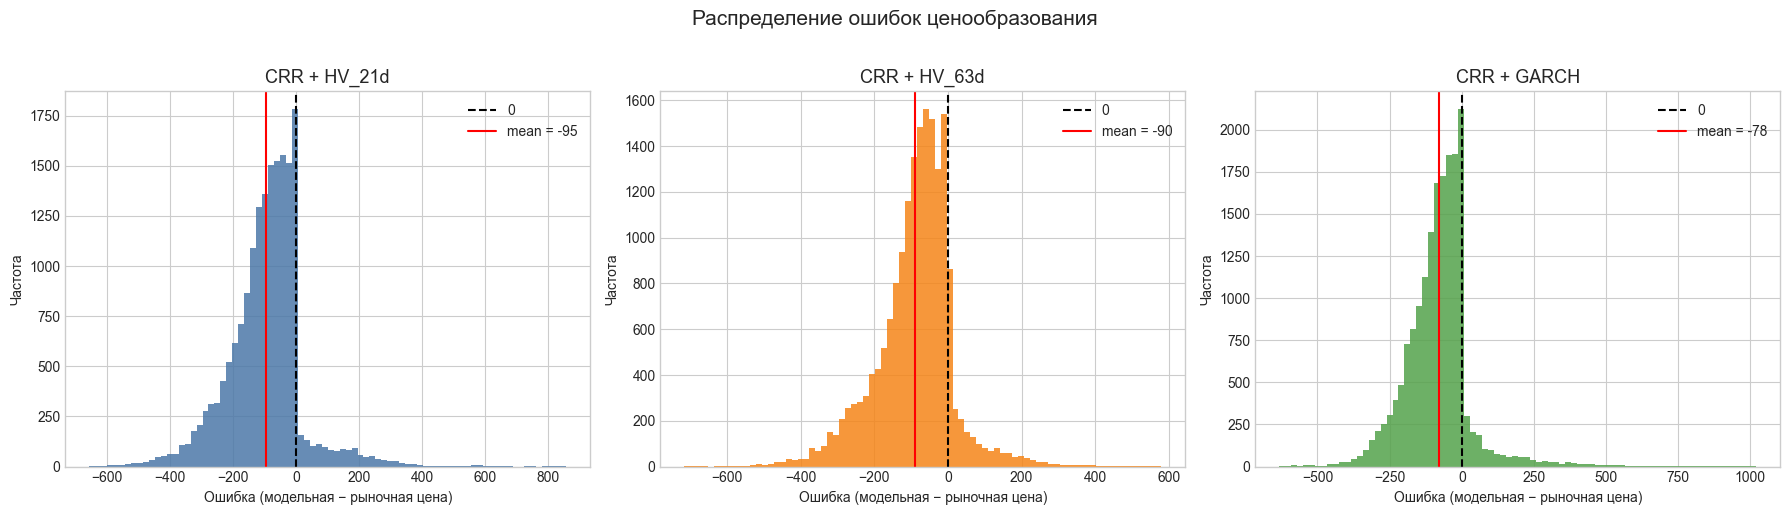

In [28]:
# Визуализация 1: Распределение ошибок по трём моделям
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_specs_err = [
    ("CRR + HV_21d", "error_crr_hv_21d", "#4C78A8"),
    ("CRR + HV_63d", "error_crr_hv_63d", "#F58518"),
    ("CRR + GARCH",  "error_crr_garch",  "#54A24B"),
]
for ax, (name, col, color) in zip(axes, model_specs_err):
    errors = american_common[col].dropna()
    ax.hist(errors, bins=80, color=color, alpha=0.85, edgecolor="none")
    ax.axvline(0,            color="black", linewidth=1.5, linestyle="--", label="0")
    ax.axvline(errors.mean(), color="red",   linewidth=1.5, linestyle="-",
               label=f"mean = {errors.mean():.0f}")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Ошибка (модельная − рыночная цена)")
    ax.set_ylabel("Частота")
    ax.legend(fontsize=10)

plt.suptitle("Распределение ошибок ценообразования", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / "fig_pres_01_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

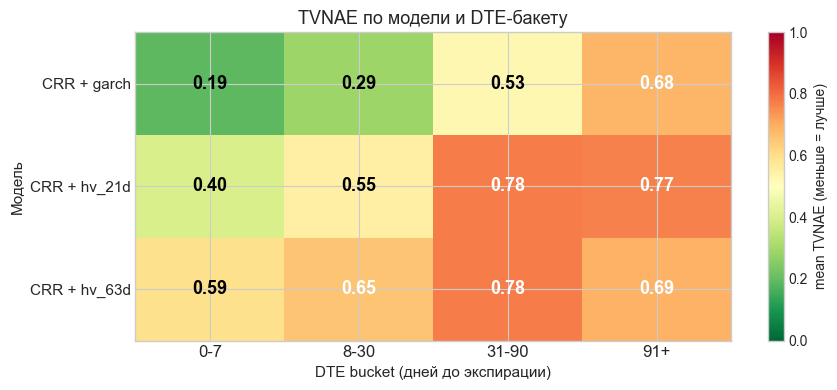

In [29]:
# Визуализация 2: Heatmap TVNAE по модели × DTE_bucket
tvnae_pivot = (
    tvnae_by_dte
    .pivot(index="model", columns="DTE_bucket", values="mean_TVNAE")
    .reindex(columns=["0-7", "8-30", "31-90", "91+"])
)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(tvnae_pivot.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(tvnae_pivot.columns)))
ax.set_xticklabels(tvnae_pivot.columns, fontsize=12)
ax.set_yticks(range(len(tvnae_pivot.index)))
ax.set_yticklabels(tvnae_pivot.index, fontsize=11)

for i in range(len(tvnae_pivot.index)):
    for j in range(len(tvnae_pivot.columns)):
        val = tvnae_pivot.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val > 0.65 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="mean TVNAE (меньше = лучше)")
ax.set_title("TVNAE по модели и DTE-бакету", fontsize=13)
ax.set_xlabel("DTE bucket (дней до экспирации)", fontsize=11)
ax.set_ylabel("Модель", fontsize=11)
plt.tight_layout()
plt.savefig(figures_dir / "fig_pres_02_tvnae_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

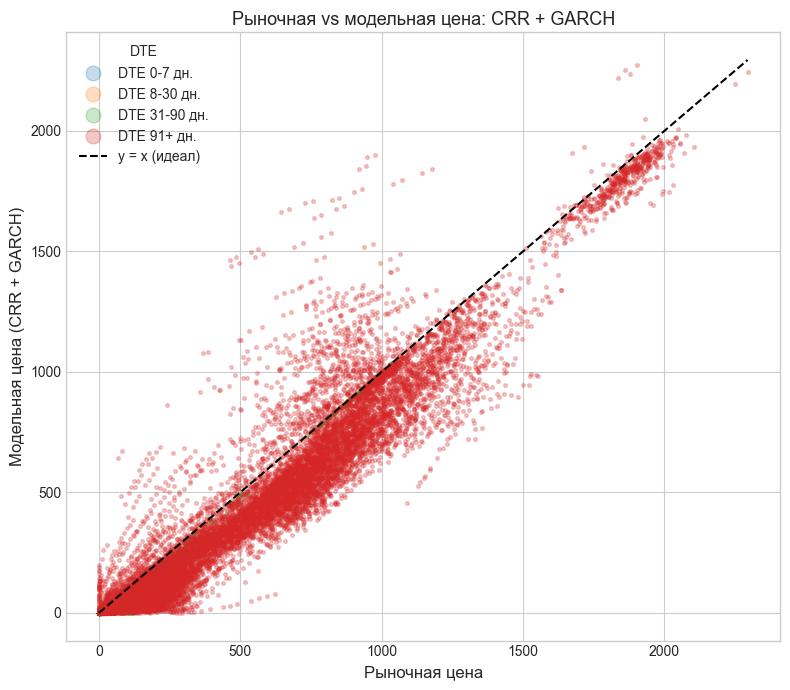

In [30]:
# Визуализация 3: Scatter рыночная цена vs модельная (CRR + GARCH)
scatter_df = (
    american_common[["market_price", "model_price_crr_garch", "DTE_bucket"]]
    .dropna()
    .copy()
)
scatter_df["DTE_bucket"] = scatter_df["DTE_bucket"].astype(str)

bucket_colors = {"0-7": "#1f77b4", "8-30": "#ff7f0e", "31-90": "#2ca02c", "91+": "#d62728"}
bucket_order  = ["0-7", "8-30", "31-90", "91+"]

fig, ax = plt.subplots(figsize=(8, 7))
for bucket in bucket_order:
    grp = scatter_df[scatter_df["DTE_bucket"] == bucket]
    ax.scatter(grp["market_price"], grp["model_price_crr_garch"],
               alpha=0.25, s=7, color=bucket_colors[bucket], label=f"DTE {bucket} дн.")

max_val = max(scatter_df["market_price"].max(), scatter_df["model_price_crr_garch"].max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.5, label="y = x (идеал)")

ax.set_xlabel("Рыночная цена", fontsize=12)
ax.set_ylabel("Модельная цена (CRR + GARCH)", fontsize=12)
ax.set_title("Рыночная vs модельная цена: CRR + GARCH", fontsize=13)
ax.legend(title="DTE", markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig(figures_dir / "fig_pres_03_scatter_market_vs_garch.png", dpi=150, bbox_inches="tight")
plt.show()

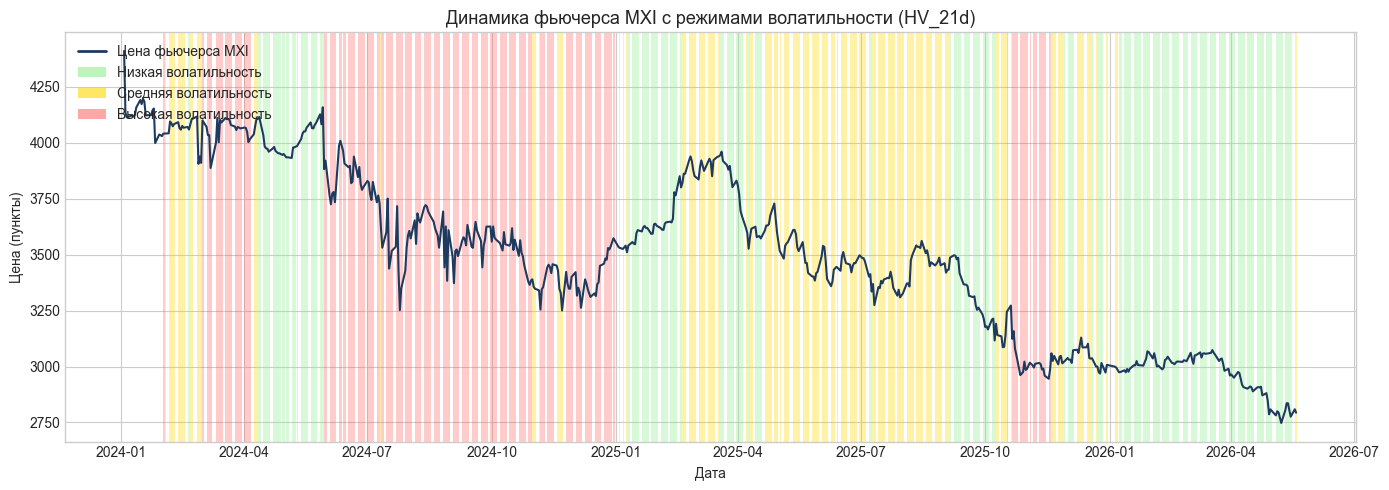

In [31]:
# Визуализация 4: Временной ряд фьючерса MXI с режимами волатильности
# Берём один ряд на дату (первый по имени базового актива — обычно ближний контракт)
ts_df = (
    underlying_daily
    .dropna(subset=["F"])
    .sort_values(["TRADEDATE", "UNDERLYING_SHORTNAME"])
    .drop_duplicates("TRADEDATE", keep="first")
    .sort_values("TRADEDATE")
    .reset_index(drop=True)
)

regime_colors = {"low_vol": "#90EE90", "mid_vol": "#FFD700", "high_vol": "#FF6B6B"}
regime_labels = {"low_vol": "Низкая волатильность", "mid_vol": "Средняя волатильность",
                 "high_vol": "Высокая волатильность"}

fig, ax = plt.subplots(figsize=(14, 5))

# Заливка фона по режимам
for regime, color in regime_colors.items():
    mask = ts_df["vol_regime"].astype(str) == regime
    for date in ts_df.loc[mask, "TRADEDATE"]:
        ax.axvspan(date, date + pd.Timedelta(days=1), color=color, alpha=0.35, linewidth=0)

ax.plot(ts_df["TRADEDATE"], ts_df["F"], color="#1f3a5f", linewidth=1.5, label="Цена фьючерса MXI")

from matplotlib.patches import Patch
legend_handles = [
    plt.Line2D([0], [0], color="#1f3a5f", linewidth=2, label="Цена фьючерса MXI"),
] + [
    Patch(facecolor=color, alpha=0.6, label=regime_labels[r])
    for r, color in regime_colors.items()
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=10)
ax.set_title("Динамика фьючерса MXI с режимами волатильности (HV_21d)", fontsize=13)
ax.set_xlabel("Дата")
ax.set_ylabel("Цена (пункты)")
plt.tight_layout()
plt.savefig(figures_dir / "fig_pres_04_mxi_vol_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

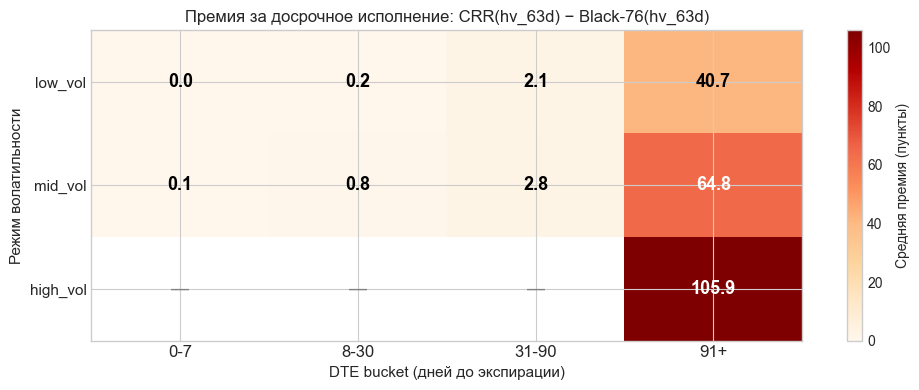

In [32]:
# Визуализация 5: Heatmap премии за досрочное исполнение (vol_regime × DTE_bucket)
prem_pivot = (
    premium_summary
    .dropna(subset=["vol_regime", "DTE_bucket"])
    .assign(vol_regime=lambda d: d["vol_regime"].astype(str),
            DTE_bucket=lambda d: d["DTE_bucket"].astype(str))
    .pivot(index="vol_regime", columns="DTE_bucket", values="mean")
    .reindex(index=["low_vol", "mid_vol", "high_vol"],
             columns=["0-7", "8-30", "31-90", "91+"])
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prem_pivot.values, cmap="OrRd", aspect="auto",
               vmin=0, vmax=float(np.nanmax(prem_pivot.values)))

ax.set_xticks(range(len(prem_pivot.columns)))
ax.set_xticklabels(prem_pivot.columns, fontsize=12)
ax.set_yticks(range(len(prem_pivot.index)))
ax.set_yticklabels(prem_pivot.index, fontsize=11)

for i in range(len(prem_pivot.index)):
    for j in range(len(prem_pivot.columns)):
        val = prem_pivot.values[i, j]
        if np.isnan(val):
            ax.text(j, i, "—", ha="center", va="center", fontsize=13, color="gray")
        else:
            text_color = "white" if val > 60 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="Средняя премия (пункты)")
ax.set_title("Премия за досрочное исполнение: CRR(hv_63d) − Black-76(hv_63d)", fontsize=12)
ax.set_xlabel("DTE bucket (дней до экспирации)", fontsize=11)
ax.set_ylabel("Режим волатильности", fontsize=11)
plt.tight_layout()
plt.savefig(figures_dir / "fig_pres_05_early_exercise_premium_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()